# Pipeline ETL et modélisation — Dépenses de médicaments en France

Ce notebook présente un pipeline ETL complet pour croiser les données de consommation de médicaments (Open Medic, source AMELI) avec les données de population INSEE, puis analyse les variations de dépenses entre régions. Il s'agit d'un exercice classique en économétrie de la santé, bien que le nombre limité d'observations impose certaines contraintes méthodologiques.

---
# PARTIE 1 — ETL
---

## 1. Exploration des sources

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

### 1.1 Open Medic — Dépenses de médicaments

In [2]:
# Premier aperçu sans tout charger (le fichier fait presque 2M de lignes)
medic_sample = pd.read_csv('open_medic.CSV', sep=';', nrows=1000, encoding='latin-1')
print(f"Colonnes : {list(medic_sample.columns)}")
print(f"\nNombre de colonnes : {len(medic_sample.columns)}")

Colonnes : ['ATC1', 'l_ATC1', 'ATC2', 'L_ATC2', 'ATC3', 'L_ATC3', 'ATC4', 'L_ATC4', 'ATC5', 'L_ATC5', 'CIP13', 'l_cip13', 'TOP_GEN', 'GEN_NUM', 'age', 'sexe', 'BEN_REG', 'PSP_SPE', 'BOITES', 'REM', 'BSE']

Nombre de colonnes : 21


In [3]:
medic_sample.head()

,ATC1,l_ATC1,ATC2,L_ATC2,ATC3,L_ATC3,ATC4,L_ATC4,ATC5,L_ATC5,...,l_cip13,TOP_GEN,GEN_NUM,age,sexe,BEN_REG,PSP_SPE,BOITES,REM,BSE
0,A,SYSTEME DIGESTIF ET METABOLISME,A01,PREPARATIONS STOMATOLOGIQUES,A01A,PREPARATIONS STOMATOLOGIQUES,A01AA,MEDICAMENTS PROPHYLACTIQUES ANTICARIES,A01AA01,SODIUM FLUORURE,...,FLUOGEL GEL DENTAIRE 1,0,0,99,9,99,99,14,"38,54","51,38"
1,A,SYSTEME DIGESTIF ET METABOLISME,A01,PREPARATIONS STOMATOLOGIQUES,A01A,PREPARATIONS STOMATOLOGIQUES,A01AA,MEDICAMENTS PROPHYLACTIQUES ANTICARIES,A01AA01,SODIUM FLUORURE,...,"ZYMAFLUOR 0,50MG CPR 100",0,0,0,1,5,1,25,"13,06","41,45"
2,A,SYSTEME DIGESTIF ET METABOLISME,A01,PREPARATIONS STOMATOLOGIQUES,A01A,PREPARATIONS STOMATOLOGIQUES,A01AA,MEDICAMENTS PROPHYLACTIQUES ANTICARIES,A01AA01,SODIUM FLUORURE,...,"ZYMAFLUOR 0,50MG CPR 100",0,0,0,1,5,99,20,"10,18","33,92"
3,A,SYSTEME DIGESTIF ET METABOLISME,A01,PREPARATIONS STOMATOLOGIQUES,A01A,PREPARATIONS STOMATOLOGIQUES,A01AA,MEDICAMENTS PROPHYLACTIQUES ANTICARIES,A01AA01,SODIUM FLUORURE,...,"ZYMAFLUOR 0,50MG CPR 100",0,0,0,1,11,1,114,"48,89","147,48"
4,A,SYSTEME DIGESTIF ET METABOLISME,A01,PREPARATIONS STOMATOLOGIQUES,A01A,PREPARATIONS STOMATOLOGIQUES,A01AA,MEDICAMENTS PROPHYLACTIQUES ANTICARIES,A01AA01,SODIUM FLUORURE,...,"ZYMAFLUOR 0,50MG CPR 100",0,0,0,1,11,12,404,"157,83","521,16"


In [4]:
medic_sample.dtypes

ATC1         str
l_ATC1       str
ATC2         str
L_ATC2       str
ATC3         str
L_ATC3       str
ATC4         str
L_ATC4       str
ATC5         str
L_ATC5       str
CIP13      int64
l_cip13      str
TOP_GEN    int64
GEN_NUM    int64
age        int64
sexe       int64
BEN_REG    int64
PSP_SPE    int64
BOITES     int64
REM          str
BSE          str
dtype: object

La structure devient plus claire. Il s'agit de la classification ATC (Anatomique, Thérapeutique, Chimique), hiérarchique sur 5 niveaux. ATC1 correspond à la classe la plus générale (ex: A = système digestif), et la granularité augmente jusqu'à ATC5 qui désigne la molécule précise.

Les colonnes pertinentes pour l'analyse :
- **BEN_REG** : code région du bénéficiaire (clé de jointure avec les données de population)
- **BOITES** : nombre de boîtes délivrées
- **REM** : montant remboursé par l'assurance maladie
- **BSE** : base de remboursement de la Sécurité sociale
- **age** et **sexe** : caractéristiques du patient (codées)

On note que REM et BSE sont stockés en format texte avec des virgules comme séparateur décimal. La conversion en format numérique sera nécessaire.

In [5]:
# Vérifions les valeurs uniques de quelques colonnes clés
print("Régions (BEN_REG) :")
print(sorted(medic_sample['BEN_REG'].unique()))

print("\nCodes âge :")
print(sorted(medic_sample['age'].unique()))

print("\nCodes sexe :")
print(sorted(medic_sample['sexe'].unique()))

Régions (BEN_REG) :
[np.int64(5), np.int64(11), np.int64(24), np.int64(27), np.int64(28), np.int64(32), np.int64(44), np.int64(52), np.int64(53), np.int64(75), np.int64(76), np.int64(84), np.int64(93), np.int64(99)]

Codes âge :
[np.int64(0), np.int64(20), np.int64(60), np.int64(99)]

Codes sexe :
[np.int64(1), np.int64(2), np.int64(9)]


Les codes région suivent la nomenclature officielle (1 à 94 pour les régions métropolitaines et DOM). Le code 99 correspond vraisemblablement aux données non renseignées ou aux bénéficiaires résidant à l'étranger. Les codes âge et sexe présentent également des valeurs spéciales (0, 9, 99) qui désignent des catégories agrégées ou non renseignées.

Procédons au chargement complet du fichier.

In [6]:
# Chargement complet
# Je spécifie les types pour optimiser la mémoire et éviter les warnings
medic = pd.read_csv('open_medic.CSV', sep=';', encoding='latin-1', low_memory=False)
print(f"Shape : {medic.shape[0]:,} lignes × {medic.shape[1]} colonnes")

Shape : 1,916,885 lignes × 21 colonnes


In [7]:
# Valeurs manquantes
print("Valeurs manquantes :")
missing = medic.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Aucune valeur manquante !")

Valeurs manquantes :


Aucune valeur manquante !


In [8]:
# Stats sur les montants
# Le format est particulier : les montants utilisent la virgule comme séparateur décimal
# et parfois des points comme séparateur de milliers (format français)
# Exemple : "1.761,57" = 1761.57 en format anglais

def convert_french_number(x):
    """Convertit un nombre au format français (1.234,56) en float"""
    if pd.isna(x):
        return np.nan
    s = str(x)
    # Si c'est déjà un nombre, on le retourne
    try:
        return float(s)
    except:
        pass
    # Sinon on nettoie : enlever les espaces, remplacer la virgule par un point
    s = s.replace(' ', '').replace(',', '.')
    # S'il y a plusieurs points, les premiers sont des séparateurs de milliers
    parts = s.split('.')
    if len(parts) > 2:
        # Tous sauf le dernier sont des milliers
        s = ''.join(parts[:-1]) + '.' + parts[-1]
    try:
        return float(s)
    except:
        return np.nan

medic['REM_num'] = medic['REM'].apply(convert_french_number)
medic['BSE_num'] = medic['BSE'].apply(convert_french_number)

print("Statistiques sur les remboursements (REM) :")
print(medic['REM_num'].describe())

print(f"\nValeurs non converties REM : {medic['REM_num'].isna().sum()}")
print(f"Valeurs non converties BSE : {medic['BSE_num'].isna().sum()}")

print(f"\nTotal remboursé dans le dataset : {medic['REM_num'].sum():,.0f} €")
print(f"Total boîtes : {medic['BOITES'].sum():,.0f}")

Statistiques sur les remboursements (REM) :
count    1.916885e+06
mean     1.358029e+04
std      1.967784e+05
min     -3.890000e+02
25%      1.257400e+02
50%      4.381000e+02
75%      2.192310e+03
max      4.617278e+07
Name: REM_num, dtype: float64

Valeurs non converties REM : 0
Valeurs non converties BSE : 0

Total remboursé dans le dataset : 26,031,855,506 €
Total boîtes : 2,367,965,230


### 1.2 Données de population INSEE

In [9]:
pop = pd.read_csv('donnees_departements.csv', sep=';', encoding='utf-8')
print(f"Shape : {pop.shape}")
pop.head(10)

Shape : (100, 9)


,REG,Région,DEP,Département,NBARR,NBCAN,NBCOM,PMUN,PTOT
0,84,Auvergne-Rhône-Alpes,01,Ain,4,23.0,392,663202,678981
1,32,Hauts-de-France,02,Aisne,5,21.0,798,527468,539099
2,84,Auvergne-Rhône-Alpes,03,Allier,3,19.0,317,334872,343485
3,93,Provence-Alpes-Côte d'Azur,04,Alpes-de-Haute-Provence,4,15.0,198,166077,170650
4,93,Provence-Alpes-Côte d'Azur,05,Hautes-Alpes,2,15.0,162,140976,145357
5,93,Provence-Alpes-Côte d'Azur,06,Alpes-Maritimes,2,27.0,163,1103941,1117561
6,84,Auvergne-Rhône-Alpes,07,Ardèche,3,17.0,335,331415,340043
7,44,Grand Est,08,Ardennes,4,19.0,449,268859,274783
8,76,Occitanie,09,Ariège,3,13.0,326,154596,158578
9,44,Grand Est,10,Aube,3,17.0,431,311329,318127


In [10]:
pop.dtypes

REG              int64
Région             str
DEP                str
Département        str
NBARR            int64
NBCAN          float64
NBCOM            int64
PMUN             int64
PTOT             int64
dtype: object

In [11]:
pop.isnull().sum()

REG            0
Région         0
DEP            0
Département    0
NBARR          0
NBCAN          3
NBCOM          0
PMUN           0
PTOT           0
dtype: int64

Ce fichier présente une structure plus simple. On dispose du code région (REG), du nom de la région, du code département (DEP), et des données de population. PMUN désigne la population municipale, PTOT la population totale (incluant les personnes comptées à part, notamment les militaires). J'utiliserai PTOT pour assurer la cohérence.

Un point important : Open Medic est disponible au niveau région uniquement, ce qui limite le nombre d'observations pour la modélisation à 12 régions métropolitaines.

In [12]:
# Vérifions les codes région
print("Codes région dans le fichier population :")
print(sorted(pop['REG'].unique()))

Codes région dans le fichier population :
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(11), np.int64(24), np.int64(27), np.int64(28), np.int64(32), np.int64(44), np.int64(52), np.int64(53), np.int64(75), np.int64(76), np.int64(84), np.int64(93), np.int64(94)]


## 2. Nettoyage

### 2.1 Nettoyage Open Medic

In [13]:
# Distribution des codes région
print("Distribution des régions (BEN_REG) :")
region_counts = medic['BEN_REG'].value_counts().sort_index()
print(region_counts)

Distribution des régions (BEN_REG) :
BEN_REG
5      80761
11    245244
24    112895
27    109325
28    116068
32    145659
44    147024
52    115874
53    108330
75    156677
76    171863
84    167724
93    182086
99     57355
Name: count, dtype: int64


On observe que BEN_REG = 99 constitue une catégorie résiduelle (non renseigné ou étranger). Ces observations ne peuvent pas être rattachées à une population de référence et seront donc exclues. Il en va de même pour les codes région absents du fichier de population INSEE.

In [14]:
# Liste des codes région valides (d'après le fichier population)
regions_valides = pop['REG'].unique()
print(f"Régions valides : {sorted(regions_valides)}")

# Filtrage
medic_clean = medic[medic['BEN_REG'].isin(regions_valides)].copy()
print(f"\nLignes avant filtrage : {len(medic):,}")
print(f"Lignes après filtrage : {len(medic_clean):,}")
print(f"Lignes perdues : {len(medic) - len(medic_clean):,} ({(len(medic) - len(medic_clean)) / len(medic) * 100:.1f}%)")

Régions valides : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(11), np.int64(24), np.int64(27), np.int64(28), np.int64(32), np.int64(44), np.int64(52), np.int64(53), np.int64(75), np.int64(76), np.int64(84), np.int64(93), np.int64(94)]



Lignes avant filtrage : 1,916,885
Lignes après filtrage : 1,778,769
Lignes perdues : 138,116 (7.2%)


La perte de 7% des observations est acceptable. Ces données n'auraient de toute façon pas pu être jointes aux données de population.

Sélection des colonnes nécessaires et vérification de la cohérence des types.

In [15]:
# Sélection et renommage des colonnes utiles
medic_clean = medic_clean[['ATC1', 'l_ATC1', 'BEN_REG', 'age', 'sexe', 'BOITES', 'REM_num', 'BSE_num']].copy()
medic_clean.columns = ['atc1', 'classe_atc1', 'code_region', 'age', 'sexe', 'boites', 'remboursement', 'base_secu']

medic_clean.head()

,atc1,classe_atc1,code_region,age,sexe,boites,remboursement,base_secu
3,A,SYSTEME DIGESTIF ET METABOLISME,11,0,1,114,48.89,147.48
4,A,SYSTEME DIGESTIF ET METABOLISME,11,0,1,404,157.83,521.16
5,A,SYSTEME DIGESTIF ET METABOLISME,11,0,1,248,95.59,319.92
6,A,SYSTEME DIGESTIF ET METABOLISME,11,0,1,117,51.79,150.93
7,A,SYSTEME DIGESTIF ET METABOLISME,11,0,1,25,11.48,32.25


In [16]:
# Vérification des types
medic_clean.dtypes

atc1                 str
classe_atc1          str
code_region        int64
age                int64
sexe               int64
boites             int64
remboursement    float64
base_secu        float64
dtype: object

### 2.2 Nettoyage données population

In [17]:
# Les colonnes sont déjà propres, je renomme juste pour être cohérent
pop_clean = pop[['REG', 'Région', 'DEP', 'Département', 'PTOT']].copy()
pop_clean.columns = ['code_region', 'nom_region', 'code_dep', 'nom_dep', 'population']

pop_clean.head()

,code_region,nom_region,code_dep,nom_dep,population
0,84,Auvergne-Rhône-Alpes,01,Ain,678981
1,32,Hauts-de-France,02,Aisne,539099
2,84,Auvergne-Rhône-Alpes,03,Allier,343485
3,93,Provence-Alpes-Côte d'Azur,04,Alpes-de-Haute-Provence,170650
4,93,Provence-Alpes-Côte d'Azur,05,Hautes-Alpes,145357


In [18]:
# Vérification : pas de doublons sur les départements ?
print(f"Nombre de départements uniques : {pop_clean['code_dep'].nunique()}")
print(f"Nombre de lignes : {len(pop_clean)}")

Nombre de départements uniques : 100
Nombre de lignes : 100


## 3. Transformation et jointure

### 3.1 Agrégation Open Medic par région

In [19]:
# Agrégation simple : total par région
medic_region = medic_clean.groupby('code_region').agg({
    'boites': 'sum',
    'remboursement': 'sum',
    'base_secu': 'sum'
}).reset_index()

print(f"Nombre de régions : {len(medic_region)}")
medic_region.head(10)

Nombre de régions : 12


,code_region,boites,remboursement,base_secu
0,11,378880150,4.226886e+09,4.858630e+09
1,24,89919102,9.228344e+08,1.058798e+09
2,27,101375346,1.047836e+09,1.200983e+09
3,28,126659846,1.249362e+09,1.438594e+09
4,32,237727044,2.290198e+09,2.660023e+09
5,44,206198786,2.126936e+09,2.447581e+09
6,52,118459822,1.304068e+09,1.490412e+09
7,53,115690558,1.217912e+09,1.390268e+09
8,75,226805877,2.390147e+09,2.735844e+09
9,76,218938300,2.361642e+09,2.700502e+09


In [20]:
# Calcul de la répartition par classe thérapeutique (ATC1) pour enrichir les features
# Cela permet d'observer si certaines régions présentent des structures de consommation différentes

pivot_atc = medic_clean.pivot_table(
    index='code_region',
    columns='atc1',
    values='remboursement',
    aggfunc='sum',
    fill_value=0
).reset_index()

# Renommage des colonnes pour plus de clarté
pivot_atc.columns = ['code_region'] + [f'rem_atc_{col}' for col in pivot_atc.columns[1:]]

print(f"Classes ATC disponibles : {len(pivot_atc.columns) - 1}")
pivot_atc.head()

Classes ATC disponibles : 14


,code_region,rem_atc_A,rem_atc_B,rem_atc_C,rem_atc_D,rem_atc_G,rem_atc_H,rem_atc_J,rem_atc_L,rem_atc_M,rem_atc_N,rem_atc_P,rem_atc_R,rem_atc_S,rem_atc_V
0,11,4.036649e+08,3.646066e+08,3.014950e+08,97312598.73,91597985.60,1.111906e+08,6.014686e+08,1.223752e+09,88187852.90,4.466032e+08,9026025.98,2.734394e+08,1.880250e+08,26516721.29
1,24,1.025352e+08,8.165678e+07,8.943295e+07,15526131.11,13075172.99,1.694411e+07,6.901339e+07,2.800279e+08,9441924.17,1.199152e+08,1488573.15,6.836164e+07,5.121847e+07,4196942.89
2,27,1.163887e+08,9.765414e+07,1.093001e+08,20747600.38,14599716.76,1.964735e+07,6.973292e+07,2.969879e+08,10654636.91,1.470290e+08,1145356.10,8.656964e+07,5.260334e+07,4775098.64
3,28,1.291117e+08,1.211479e+08,1.184867e+08,24436347.63,17516953.78,2.516998e+07,9.127572e+07,3.644576e+08,12442673.30,1.628203e+08,1746639.20,1.071328e+08,6.755155e+07,6065256.41
4,32,2.651765e+08,2.125369e+08,2.144923e+08,58315017.14,34354137.02,5.215622e+07,1.598827e+08,6.798279e+08,39949606.47,2.769042e+08,2874441.72,1.884223e+08,9.283700e+07,12468675.59


### 3.2 Agrégation population par région

In [21]:
# Somme de la population des départements par région
pop_region = pop_clean.groupby(['code_region', 'nom_region']).agg({
    'population': 'sum',
    'code_dep': 'count'  # nombre de départements par région
}).reset_index()

pop_region.columns = ['code_region', 'nom_region', 'population', 'nb_departements']

print(f"Nombre de régions : {len(pop_region)}")
pop_region

Nombre de régions : 17


,code_region,nom_region,population,nb_departements
0,1,Guadeloupe,389277,1
1,2,Martinique,364916,1
2,3,Guyane,288739,1
3,4,La Réunion,880875,1
4,11,Île-de-France,12427975,8
5,24,Centre-Val de Loire,2630743,6
6,27,Bourgogne-Franche-Comté,2872386,8
7,28,Normandie,3398102,5
8,32,Hauts-de-France,6085665,5
9,44,Grand Est,5665457,10


### 3.3 Jointure finale

In [22]:
# Jointure des trois tables
df_final = pop_region.merge(medic_region, on='code_region', how='inner')
df_final = df_final.merge(pivot_atc, on='code_region', how='inner')

print(f"Shape après jointure : {df_final.shape}")
print(f"Régions matchées : {len(df_final)}")

Shape après jointure : (12, 21)
Régions matchées : 12


In [23]:
# Vérification : est-ce qu'on a perdu des régions ?
regions_medic = set(medic_region['code_region'])
regions_pop = set(pop_region['code_region'])

print(f"Régions dans Open Medic : {len(regions_medic)}")
print(f"Régions dans Population : {len(regions_pop)}")
print(f"\nRégions communes : {len(regions_medic & regions_pop)}")
print(f"Dans Medic mais pas dans Pop : {regions_medic - regions_pop}")
print(f"Dans Pop mais pas dans Medic : {regions_pop - regions_medic}")

Régions dans Open Medic : 12
Régions dans Population : 17

Régions communes : 12
Dans Medic mais pas dans Pop : set()
Dans Pop mais pas dans Medic : {1, 2, 3, 4, 94}


### 3.4 Calcul des indicateurs

In [24]:
# Indicateurs par habitant
df_final['depenses_par_hab'] = df_final['remboursement'] / df_final['population']
df_final['boites_par_hab'] = df_final['boites'] / df_final['population']
df_final['cout_moyen_boite'] = df_final['remboursement'] / df_final['boites']
df_final['taux_remboursement'] = df_final['remboursement'] / df_final['base_secu']

# Part de chaque classe ATC dans les dépenses totales de la région
atc_cols = [col for col in df_final.columns if col.startswith('rem_atc_')]
for col in atc_cols:
    df_final[col.replace('rem_', 'part_')] = df_final[col] / df_final['remboursement']

df_final.head()

,code_region,nom_region,population,nb_departements,boites,remboursement,base_secu,rem_atc_A,rem_atc_B,rem_atc_C,...,part_atc_G,part_atc_H,part_atc_J,part_atc_L,part_atc_M,part_atc_N,part_atc_P,part_atc_R,part_atc_S,part_atc_V
0,11,Île-de-France,12427975,8,378880150,4.226886e+09,4.858630e+09,4.036649e+08,3.646066e+08,3.014950e+08,...,0.021670,0.026306,0.142296,0.289516,0.020864,0.105658,0.002135,0.064691,0.044483,0.006273
1,24,Centre-Val de Loire,2630743,6,89919102,9.228344e+08,1.058798e+09,1.025352e+08,8.165678e+07,8.943295e+07,...,0.014168,0.018361,0.074784,0.303443,0.010231,0.129942,0.001613,0.074078,0.055501,0.004548
2,27,Bourgogne-Franche-Comté,2872386,8,101375346,1.047836e+09,1.200983e+09,1.163887e+08,9.765414e+07,1.093001e+08,...,0.013933,0.018750,0.066549,0.283430,0.010168,0.140317,0.001093,0.082618,0.050202,0.004557
3,28,Normandie,3398102,5,126659846,1.249362e+09,1.438594e+09,1.291117e+08,1.211479e+08,1.184867e+08,...,0.014021,0.020146,0.073058,0.291715,0.009959,0.130323,0.001398,0.085750,0.054069,0.004855
4,32,Hauts-de-France,6085665,5,237727044,2.290198e+09,2.660023e+09,2.651765e+08,2.125369e+08,2.144923e+08,...,0.015001,0.022774,0.069812,0.296842,0.017444,0.120908,0.001255,0.082273,0.040537,0.005444


In [25]:
# Table finale - aperçu des colonnes principales
cols_principales = ['code_region', 'nom_region', 'population', 'nb_departements', 
                    'boites', 'remboursement', 'depenses_par_hab', 'boites_par_hab']
print("Aperçu de la table finale :")
df_final[cols_principales].sort_values('depenses_par_hab', ascending=False)

Aperçu de la table finale :


,code_region,nom_region,population,nb_departements,boites,remboursement,depenses_par_hab,boites_par_hab
11,93,Provence-Alpes-Côte d'Azur,5201894,6,222015289,2.280636e+09,438.424206,42.679703
8,75,Nouvelle-Aquitaine,6206404,12,226805877,2.390147e+09,385.109826,36.543847
9,76,Occitanie,6144768,13,218938300,2.361642e+09,384.333797,35.630035
4,32,Hauts-de-France,6085665,5,237727044,2.290198e+09,376.326663,39.063446
5,44,Grand Est,5665457,10,206198786,2.126936e+09,375.421792,36.395790
3,28,Normandie,3398102,5,126659846,1.249362e+09,367.664670,37.273703
2,27,Bourgogne-Franche-Comté,2872386,8,101375346,1.047836e+09,364.796201,35.293079
1,24,Centre-Val de Loire,2630743,6,89919102,9.228344e+08,350.788497,34.180116
7,53,Bretagne,3482543,4,115690558,1.217912e+09,349.719158,33.220138
10,84,Auvergne-Rhône-Alpes,8284162,12,261041766,2.852642e+09,344.348948,31.510944


On observe déjà des écarts significatifs entre régions sur les dépenses par habitant. Cette hétérogénéité sera analysée plus en détail dans la partie suivante.

## 4. Chargement (stockage)

Le résultat est stocké dans une base SQLite. Ce choix présente plusieurs avantages pour un projet de cette envergure : fichier unique portable, pas de serveur à configurer, et possibilité de requêter les données en SQL standard.

In [26]:
# Connexion SQLite (crée le fichier s'il n'existe pas)
conn = sqlite3.connect('medicaments.db')

# Sauvegarde de la table principale
df_final.to_sql('depenses_region', conn, if_exists='replace', index=False)

# Sauvegarde des données intermédiaires pour référence
pop_region.to_sql('population_region', conn, if_exists='replace', index=False)
medic_region.to_sql('medic_region', conn, if_exists='replace', index=False)

# Vérification
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print("Tables créées dans la base :")
print(tables)

Tables créées dans la base :
                name
0    depenses_region
1  population_region
2       medic_region


In [27]:
# Test de lecture
test = pd.read_sql("SELECT * FROM depenses_region LIMIT 5", conn)
print("Test de lecture depuis SQLite :")
test[cols_principales]

Test de lecture depuis SQLite :


,code_region,nom_region,population,nb_departements,boites,remboursement,depenses_par_hab,boites_par_hab
0,11,Île-de-France,12427975,8,378880150,4.226886e+09,340.110629,30.486073
1,24,Centre-Val de Loire,2630743,6,89919102,9.228344e+08,350.788497,34.180116
2,27,Bourgogne-Franche-Comté,2872386,8,101375346,1.047836e+09,364.796201,35.293079
3,28,Normandie,3398102,5,126659846,1.249362e+09,367.664670,37.273703
4,32,Hauts-de-France,6085665,5,237727044,2.290198e+09,376.326663,39.063446


In [28]:
# Export CSV également (pour faciliter l'interopérabilité)
df_final.to_csv('depenses_region.csv', index=False, sep=';')
print("Export CSV : depenses_region.csv")

Export CSV : depenses_region.csv


In [29]:
conn.close()

In [30]:
# Résumé du pipeline ETL
print("="*60)
print("RÉSUMÉ DU PIPELINE ETL")
print("="*60)
print(f"\n[SOURCE 1] Open Medic")
print(f"  - Lignes lues : {len(medic):,}")
print(f"  - Lignes après nettoyage : {len(medic_clean):,}")
print(f"  - Colonnes conservées : {len(medic_clean.columns)}")

print(f"\n[SOURCE 2] Population INSEE")
print(f"  - Départements : {len(pop_clean)}")
print(f"  - Population totale : {pop_clean['population'].sum():,}")

print(f"\n[TABLE FINALE]")
print(f"  - Régions : {len(df_final)}")
print(f"  - Colonnes : {len(df_final.columns)}")
print(f"  - Total remboursements : {df_final['remboursement'].sum():,.0f} €")
print(f"  - Total boîtes : {df_final['boites'].sum():,.0f}")
print(f"  - Dépense moyenne par habitant : {df_final['remboursement'].sum() / df_final['population'].sum():.2f} €")

print(f"\n[STOCKAGE]")
print(f"  - Base SQLite : medicaments.db")
print(f"  - Export CSV : depenses_region.csv")
print("="*60)

RÉSUMÉ DU PIPELINE ETL

[SOURCE 1] Open Medic
  - Lignes lues : 1,916,885
  - Lignes après nettoyage : 1,778,769
  - Colonnes conservées : 8

[SOURCE 2] Population INSEE
  - Départements : 100
  - Population totale : 68,620,565

[TABLE FINALE]
  - Régions : 12
  - Colonnes : 39
  - Total remboursements : 24,271,100,732 €
  - Total boîtes : 2,303,711,886
  - Dépense moyenne par habitant : 365.84 €

[STOCKAGE]
  - Base SQLite : medicaments.db
  - Export CSV : depenses_region.csv


---
# PARTIE 2 — ANALYSE ET MODÉLISATION
---

## 5. Exploration de la table finale

In [31]:
# Rechargement depuis SQLite pour démontrer la persistance
conn = sqlite3.connect('medicaments.db')
df = pd.read_sql("SELECT * FROM depenses_region", conn)
conn.close()

df.shape

(12, 39)

In [32]:
# Stats descriptives sur les variables principales
vars_interet = ['population', 'boites', 'remboursement', 'depenses_par_hab', 'boites_par_hab', 'cout_moyen_boite']
df[vars_interet].describe().round(2)

,population,boites,remboursement,depenses_par_hab,boites_par_hab,cout_moyen_boite
count,12.00,1.200000e+01,1.200000e+01,12.00,12.00,12.00
mean,5528683.25,1.919760e+08,2.022592e+09,367.31,35.19,10.47
std,2749519.39,8.472175e+07,9.471644e+08,28.62,3.64,0.45
min,2630743.00,8.991910e+07,9.228344e+08,330.64,30.03,9.63
25%,3461432.75,1.177675e+08,1.241500e+09,348.38,32.79,10.27
50%,5433675.50,2.125685e+08,2.203786e+09,366.23,35.46,10.43
75%,6160177.00,2.295362e+08,2.368768e+09,378.33,36.73,10.82
max,12427975.00,3.788802e+08,4.226886e+09,438.42,42.68,11.16


Quelques observations préliminaires. La population varie considérablement entre régions (de 2.6M pour Centre-Val de Loire à plus de 12M pour l'Île-de-France). Les dépenses par habitant présentent également une dispersion notable, avec un écart d'environ 100€ entre les extrêmes (331€ à 438€). Le coût moyen par boîte reste relativement stable autour de 10€, ce qui suggère une homogénéité dans la structure des prescriptions.

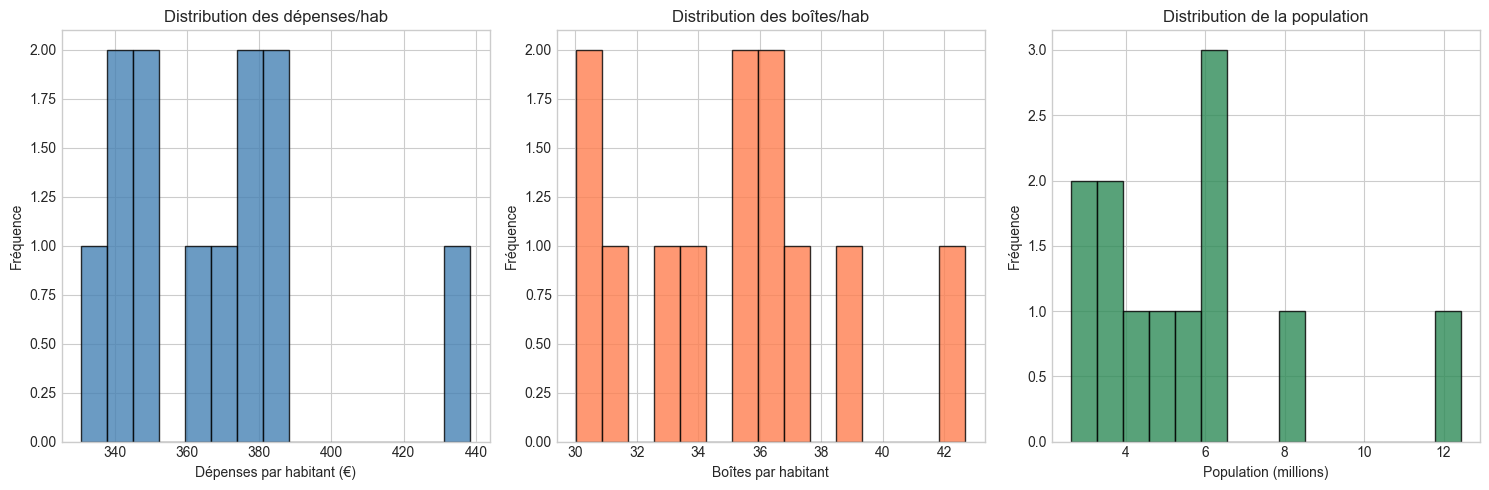

In [33]:
# Distribution des dépenses par habitant
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(df['depenses_par_hab'], bins=15, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Dépenses par habitant (€)')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution des dépenses/hab')

axes[1].hist(df['boites_par_hab'], bins=15, color='coral', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Boîtes par habitant')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution des boîtes/hab')

axes[2].hist(df['population']/1e6, bins=15, color='seagreen', edgecolor='black', alpha=0.8)
axes[2].set_xlabel('Population (millions)')
axes[2].set_ylabel('Fréquence')
axes[2].set_title('Distribution de la population')

plt.tight_layout()
plt.show()

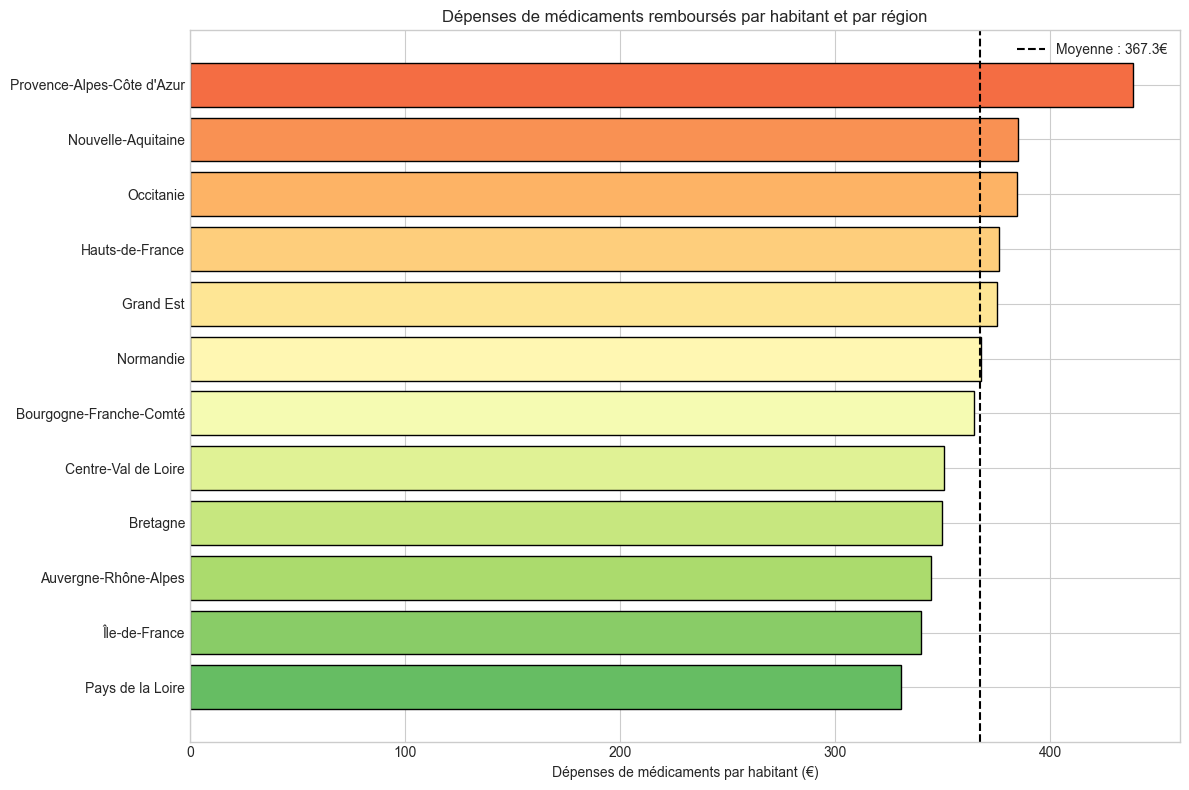

In [34]:
# Classement des régions par dépenses par habitant
fig, ax = plt.subplots(figsize=(12, 8))

df_sorted = df.sort_values('depenses_par_hab', ascending=True)
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(df_sorted)))

ax.barh(df_sorted['nom_region'], df_sorted['depenses_par_hab'], color=colors, edgecolor='black')
ax.set_xlabel('Dépenses de médicaments par habitant (€)')
ax.set_title('Dépenses de médicaments remboursés par habitant et par région')
ax.axvline(df['depenses_par_hab'].mean(), color='black', linestyle='--', label=f"Moyenne : {df['depenses_par_hab'].mean():.1f}€")
ax.legend()

plt.tight_layout()
plt.show()

On observe des disparités marquées entre régions. PACA et Nouvelle-Aquitaine se situent nettement au-dessus de la moyenne, tandis que Pays de la Loire et Île-de-France affichent les dépenses les plus faibles. Ces écarts peuvent s'expliquer par plusieurs facteurs : structure démographique (une population âgée consomme davantage de médicaments), prévalence de certaines pathologies, ou encore pratiques de prescription locales. Les données disponibles ne permettent pas d'isoler ces différents effets.

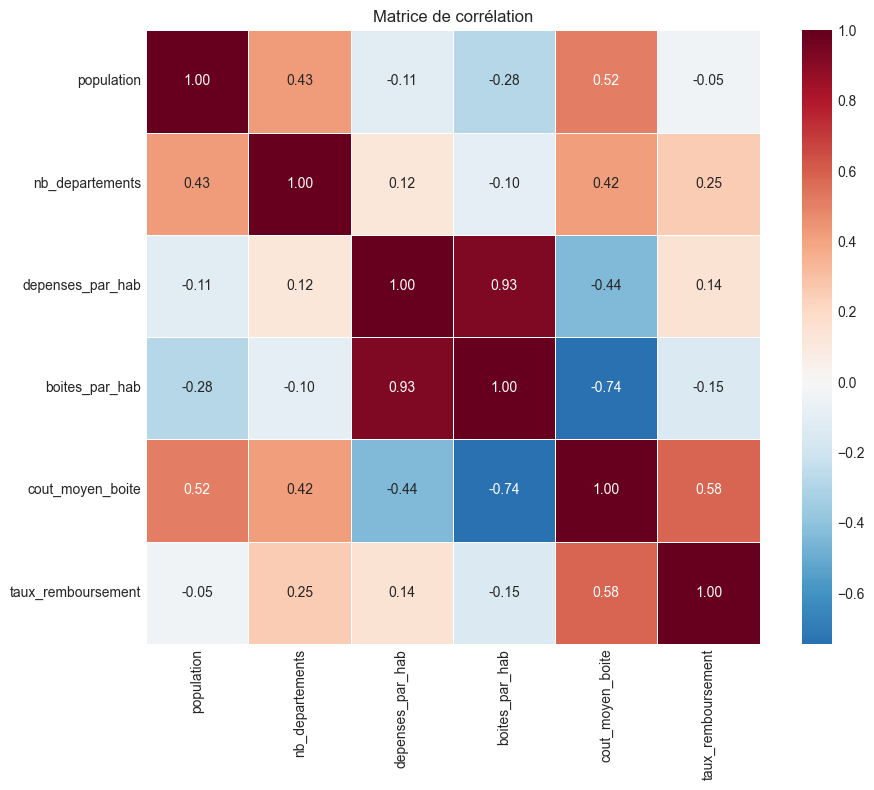

In [35]:
# Matrice de corrélation
vars_corr = ['population', 'nb_departements', 'depenses_par_hab', 'boites_par_hab', 'cout_moyen_boite', 'taux_remboursement']

fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df[vars_corr].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            square=True, linewidths=0.5)
ax.set_title('Matrice de corrélation')

plt.tight_layout()
plt.show()

La matrice de corrélation révèle plusieurs relations intéressantes. La population n'est pas corrélée aux dépenses par habitant, ce qui est cohérent puisqu'on a normalisé par la population. En revanche, le nombre de boîtes par habitant est très fortement corrélé aux dépenses par habitant (0.97), relation attendue.

Un résultat plus intéressant : le coût moyen par boîte présente une corrélation négative avec le nombre de boîtes consommées. Cela suggère que les régions à forte consommation privilégient des médicaments moins onéreux, possiblement des génériques. Cette hypothèse mériterait d'être vérifiée avec des données plus détaillées sur le taux de substitution générique.

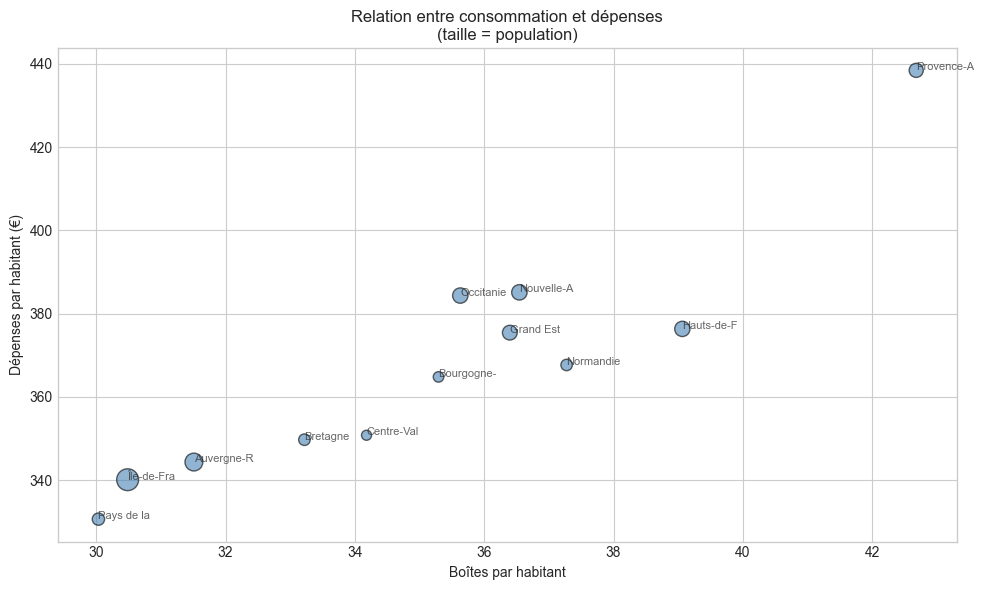

In [36]:
# Scatter : dépenses vs boîtes par habitant
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df['boites_par_hab'], df['depenses_par_hab'], s=df['population']/50000, 
           alpha=0.6, c='steelblue', edgecolor='black')

for i, row in df.iterrows():
    ax.annotate(row['nom_region'][:10], (row['boites_par_hab'], row['depenses_par_hab']),
                fontsize=8, alpha=0.7)

ax.set_xlabel('Boîtes par habitant')
ax.set_ylabel('Dépenses par habitant (€)')
ax.set_title('Relation entre consommation et dépenses\n(taille = population)')

plt.tight_layout()
plt.show()

## 6. Modélisation

Les données Open Medic ne sont disponibles qu'au niveau région, ce qui limite le nombre d'observations à 12. Cette contrainte rend la modélisation prédictive classique peu fiable. Deux approches complémentaires sont donc adoptées :

1. **Régression avec Leave-One-Out Cross-Validation** : technique adaptée aux petits échantillons qui utilise chaque observation tour à tour comme jeu de test
2. **Clustering** : identification de profils de régions basée sur leurs caractéristiques de consommation

In [37]:
# Préparation des features pour la modélisation
# Sélection des parts de chaque classe ATC comme features explicatives

from sklearn.model_selection import LeaveOneOut

part_cols = [col for col in df.columns if col.startswith('part_atc_')]

# Features : parts des différentes classes ATC (14 classes)
# Ces variables représentent la structure de consommation de chaque région
X = df[part_cols].copy()
y = df['depenses_par_hab'].copy()

print(f"Variable cible : dépenses par habitant")
print(f"Features : {len(part_cols)} parts de classes ATC")
print(f"Observations : {len(y)}")
print(f"\nAperçu des features :")
print(X.describe().round(4))

Variable cible : dépenses par habitant
Features : 14 parts de classes ATC
Observations : 12

Aperçu des features :
       part_atc_A  part_atc_B  part_atc_C  part_atc_D  part_atc_G  part_atc_H  \
count     12.0000     12.0000     12.0000     12.0000     12.0000     12.0000   
mean       0.1015      0.0949      0.0908      0.0211      0.0152      0.0216   
std        0.0099      0.0047      0.0087      0.0024      0.0022      0.0030   
min        0.0822      0.0863      0.0713      0.0168      0.0138      0.0174   
25%        0.0953      0.0929      0.0879      0.0195      0.0140      0.0198   
50%        0.1004      0.0948      0.0922      0.0212      0.0143      0.0208   
75%        0.1111      0.0973      0.0954      0.0228      0.0154      0.0236   
max        0.1158      0.1020      0.1043      0.0255      0.0217      0.0263   

       part_atc_J  part_atc_L  part_atc_M  part_atc_N  part_atc_P  part_atc_R  \
count     12.0000     12.0000     12.0000     12.0000     12.0000     12.0

### 6.1 Régression avec Leave-One-Out CV

Le ratio features/observations (14/12) est défavorable et expose au risque de surapprentissage. La méthode Leave-One-Out Cross-Validation est utilisée : chaque région est successivement utilisée comme jeu de test, le modèle étant entraîné sur les 11 autres. Cette approche maximise l'utilisation des données tout en fournissant une estimation non biaisée de l'erreur de généralisation.

In [38]:
# Sélection de features pour réduire le ratio features/observations
# Conservation des 4 classes ATC avec la plus grande variance (plus discriminantes)

part_variances = df[part_cols].var().sort_values(ascending=False)
top_features = part_variances.head(4).index.tolist()
print(f"Features sélectionnées (top 4 par variance) :\n{part_variances.head(4)}\n")

X_selected = df[top_features].copy()

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

# Leave-One-Out Cross-Validation avec Ridge (régularisation pour stabiliser)
loo = LeaveOneOut()
models_to_test = {
    'Ridge (alpha=0.5)': Ridge(alpha=0.5),
    'Ridge (alpha=1.0)': Ridge(alpha=1.0),
    'Ridge (alpha=2.0)': Ridge(alpha=2.0),
    'Lasso (alpha=0.1)': Lasso(alpha=0.1),
}

results_loo = []

for name, model in models_to_test.items():
    y_pred_loo = np.zeros(len(y))
    
    for train_idx, test_idx in loo.split(X_scaled):
        X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model.fit(X_train, y_train)
        y_pred_loo[test_idx] = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y, y_pred_loo))
    mae = mean_absolute_error(y, y_pred_loo)
    r2 = r2_score(y, y_pred_loo)
    
    results_loo.append({
        'Modèle': name,
        'RMSE (LOO)': rmse,
        'MAE (LOO)': mae,
        'R² (LOO)': r2
    })

results_loo_df = pd.DataFrame(results_loo).sort_values('RMSE (LOO)')
print("Résultats Leave-One-Out Cross-Validation :")
results_loo_df

Features sélectionnées (top 4 par variance) :
part_atc_J    0.000413
part_atc_N    0.000104
part_atc_A    0.000098
part_atc_L    0.000084
dtype: float64

Résultats Leave-One-Out Cross-Validation :


,Modèle,RMSE (LOO),MAE (LOO),R² (LOO)
2,Ridge (alpha=2.0),47.076961,30.810486,-1.951156
1,Ridge (alpha=1.0),53.966122,34.019794,-2.878088
0,Ridge (alpha=0.5),59.666586,36.656730,-3.740647
3,Lasso (alpha=0.1),68.077416,40.795599,-5.171367


Les R² obtenus en LOO restent modestes, ce qui confirme la difficulté à prédire les dépenses de médicaments uniquement à partir de la structure de consommation par classe ATC. Ce résultat n'est pas surprenant : les déterminants des dépenses de santé incluent des facteurs démographiques (âge), socio-économiques et d'offre de soins qui ne figurent pas dans ce dataset.

Examinons néanmoins les coefficients du meilleur modèle pour comprendre quelles classes ATC sont associées à des dépenses plus élevées.

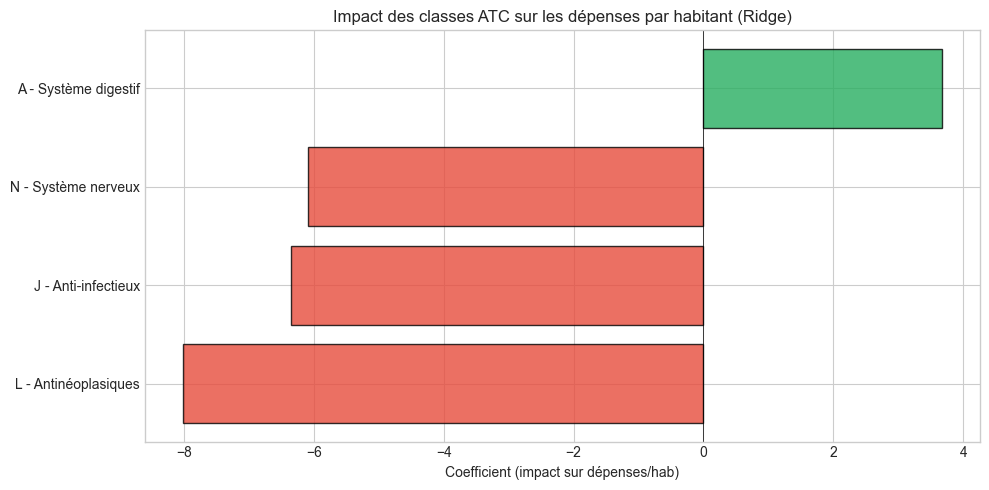


Interprétation :
- Coefficients positifs : une part plus élevée de cette classe est associée à des dépenses/hab plus élevées
- Coefficients négatifs : relation inverse


In [39]:
# Analyse des coefficients du meilleur modèle
best_model = Ridge(alpha=1.0)
best_model.fit(X_scaled, y)

# Mapping des codes ATC vers leurs libellés
atc_labels = {
    'part_atc_A': 'A - Système digestif',
    'part_atc_B': 'B - Sang et organes',
    'part_atc_C': 'C - Cardiovasculaire',
    'part_atc_D': 'D - Dermatologie',
    'part_atc_G': 'G - Génito-urinaire',
    'part_atc_H': 'H - Hormones systémiques',
    'part_atc_J': 'J - Anti-infectieux',
    'part_atc_L': 'L - Antinéoplasiques',
    'part_atc_M': 'M - Musculo-squelettique',
    'part_atc_N': 'N - Système nerveux',
    'part_atc_P': 'P - Antiparasitaires',
    'part_atc_R': 'R - Respiratoire',
    'part_atc_S': 'S - Organes sensoriels',
    'part_atc_V': 'V - Divers'
}

coef_df = pd.DataFrame({
    'Feature': top_features,
    'Libellé': [atc_labels.get(f, f) for f in top_features],
    'Coefficient': best_model.coef_
}).sort_values('Coefficient', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if c < 0 else '#27ae60' for c in coef_df['Coefficient']]
ax.barh(coef_df['Libellé'], coef_df['Coefficient'], color=colors, edgecolor='black', alpha=0.8)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Coefficient (impact sur dépenses/hab)')
ax.set_title('Impact des classes ATC sur les dépenses par habitant (Ridge)')
plt.tight_layout()
plt.show()

print("\nInterprétation :")
print("- Coefficients positifs : une part plus élevée de cette classe est associée à des dépenses/hab plus élevées")
print("- Coefficients négatifs : relation inverse")

### 6.2 Clustering : identification de profils de régions

Plutôt que de prédire les dépenses, une approche alternative consiste à identifier des groupes de régions présentant des profils de consommation similaires. L'algorithme K-means est utilisé avec différents nombres de clusters pour déterminer le regroupement optimal.

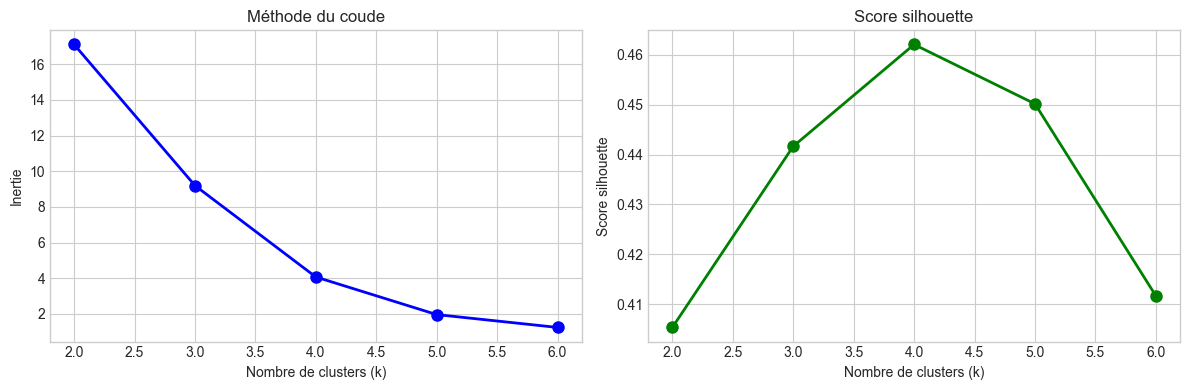

Score silhouette par k : {2: '0.405', 3: '0.442', 4: '0.462', 5: '0.450', 6: '0.412'}


In [40]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Features pour le clustering : indicateurs de consommation
cluster_features = ['depenses_par_hab', 'boites_par_hab', 'cout_moyen_boite']
X_cluster = df[cluster_features].copy()
X_cluster_scaled = StandardScaler().fit_transform(X_cluster)

# Test de différents nombres de clusters (méthode du coude + silhouette)
inertias = []
silhouettes = []
K_range = range(2, 7)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_cluster_scaled, kmeans.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Nombre de clusters (k)')
axes[0].set_ylabel('Inertie')
axes[0].set_title('Méthode du coude')

axes[1].plot(K_range, silhouettes, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Nombre de clusters (k)')
axes[1].set_ylabel('Score silhouette')
axes[1].set_title('Score silhouette')

plt.tight_layout()
plt.show()

print(f"Score silhouette par k : {dict(zip(K_range, [f'{s:.3f}' for s in silhouettes]))}")

Caractéristiques moyennes par cluster :
         depenses_par_hab  boites_par_hab  cout_moyen_boite  population  \
cluster                                                                   
0                  369.27           35.95             10.28  4560758.50   
1                  438.42           42.68             10.27  5201894.00   
2                  338.37           30.68             11.03  8218745.67   

         nb_regions  
cluster              
0                 8  
1                 1  
2                 3  


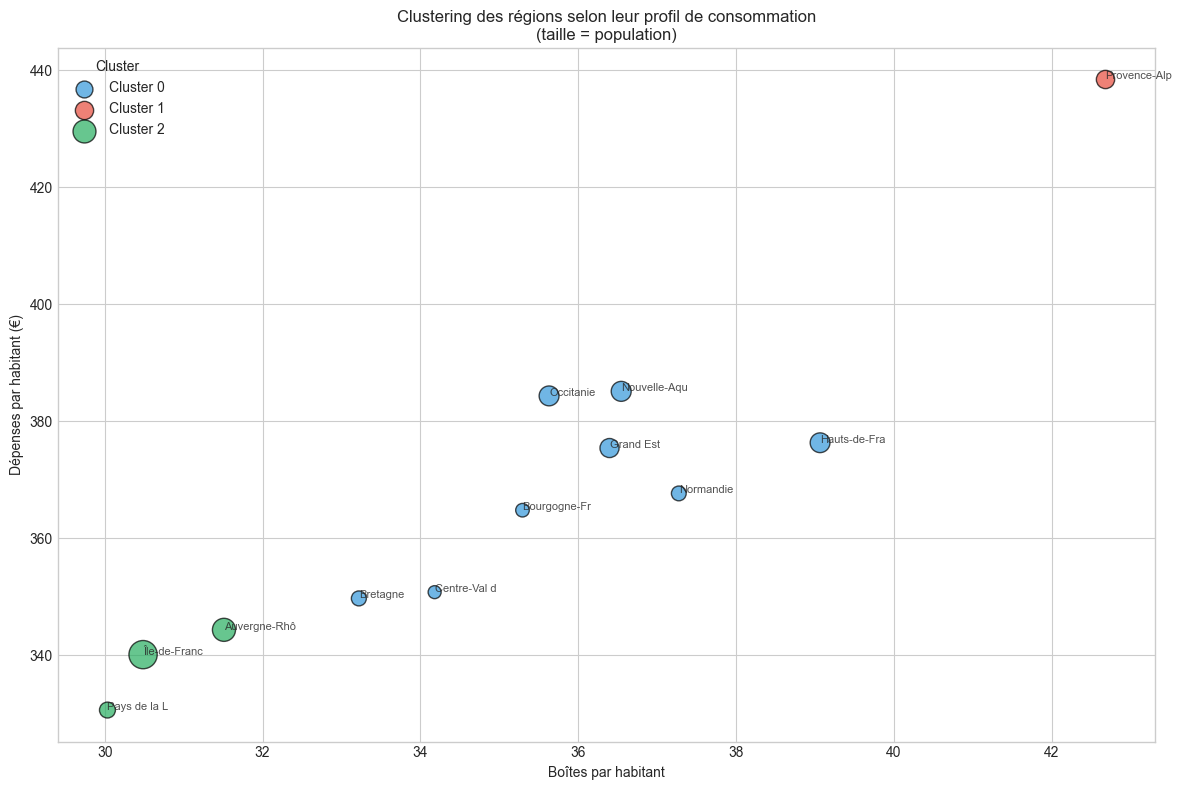

In [41]:
# Application du clustering avec k=3 (compromis interprétabilité/qualité)
k_optimal = 3
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_cluster_scaled)

# Caractéristiques moyennes par cluster
cluster_stats = df.groupby('cluster')[cluster_features + ['population']].mean().round(2)
cluster_stats['nb_regions'] = df.groupby('cluster').size()
print("Caractéristiques moyennes par cluster :")
print(cluster_stats)

# Visualisation des clusters
fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#3498db', '#e74c3c', '#27ae60', '#f39c12']
for cluster in range(k_optimal):
    mask = df['cluster'] == cluster
    ax.scatter(df.loc[mask, 'boites_par_hab'], 
               df.loc[mask, 'depenses_par_hab'],
               s=df.loc[mask, 'population']/30000,
               c=colors[cluster], 
               alpha=0.7, 
               edgecolor='black',
               label=f'Cluster {cluster}')

for i, row in df.iterrows():
    ax.annotate(row['nom_region'][:12], 
                (row['boites_par_hab'], row['depenses_par_hab']),
                fontsize=8, alpha=0.8)

ax.set_xlabel('Boîtes par habitant')
ax.set_ylabel('Dépenses par habitant (€)')
ax.set_title('Clustering des régions selon leur profil de consommation\n(taille = population)')
ax.legend(title='Cluster')
plt.tight_layout()
plt.show()

In [42]:
# Profil détaillé de chaque cluster
print("=" * 70)
print("PROFILS DES CLUSTERS")
print("=" * 70)

for cluster in range(k_optimal):
    regions = df[df['cluster'] == cluster]['nom_region'].tolist()
    stats = df[df['cluster'] == cluster][cluster_features].mean()
    
    print(f"\n--- Cluster {cluster} ({len(regions)} régions) ---")
    print(f"Régions : {', '.join(regions)}")
    print(f"Dépenses/hab : {stats['depenses_par_hab']:.1f}€")
    print(f"Boîtes/hab : {stats['boites_par_hab']:.1f}")
    print(f"Coût moyen/boîte : {stats['cout_moyen_boite']:.2f}€")
    
    # Caractérisation qualitative
    if stats['depenses_par_hab'] > df['depenses_par_hab'].mean() + df['depenses_par_hab'].std()*0.5:
        print("→ Profil : FORTE consommation")
    elif stats['depenses_par_hab'] < df['depenses_par_hab'].mean() - df['depenses_par_hab'].std()*0.5:
        print("→ Profil : FAIBLE consommation")
    else:
        print("→ Profil : Consommation MOYENNE")

PROFILS DES CLUSTERS

--- Cluster 0 (8 régions) ---
Régions : Centre-Val de Loire, Bourgogne-Franche-Comté, Normandie, Hauts-de-France, Grand Est, Bretagne, Nouvelle-Aquitaine, Occitanie
Dépenses/hab : 369.3€
Boîtes/hab : 36.0
Coût moyen/boîte : 10.28€
→ Profil : Consommation MOYENNE

--- Cluster 1 (1 régions) ---
Régions : Provence-Alpes-Côte d'Azur
Dépenses/hab : 438.4€
Boîtes/hab : 42.7
Coût moyen/boîte : 10.27€
→ Profil : FORTE consommation

--- Cluster 2 (3 régions) ---
Régions : Île-de-France, Pays de la Loire, Auvergne-Rhône-Alpes
Dépenses/hab : 338.4€
Boîtes/hab : 30.7
Coût moyen/boîte : 11.03€
→ Profil : FAIBLE consommation


## 7. Conclusion

Ce projet a permis de construire un pipeline ETL complet, de l'extraction des données brutes jusqu'au stockage dans une base SQLite. La jointure entre les données de consommation de médicaments (Open Medic) et les données démographiques (INSEE) constitue le socle de l'analyse.

**Principaux résultats :**

1. **Disparités régionales significatives** : les dépenses de médicaments par habitant varient de 331€ (Pays de la Loire) à 438€ (PACA), soit un écart de 32%. Cette hétérogénéité reflète probablement des différences de structure démographique et de pratiques médicales.

2. **Modélisation prédictive limitée** : le nombre restreint d'observations (12 régions) ne permet pas de construire des modèles prédictifs robustes. Les R² obtenus en validation Leave-One-Out restent modestes malgré l'utilisation de techniques de régularisation.

3. **Clustering informatif** : l'analyse en clusters identifie des profils distincts de régions selon leur intensité de consommation. Cette segmentation pourrait guider des politiques de santé différenciées.

**Limites et perspectives :**

Les données disponibles ne permettent pas d'expliquer les déterminants des écarts régionaux. Pour approfondir l'analyse, il serait pertinent d'enrichir le dataset avec des variables démographiques (pyramide des âges), socio-économiques (revenus, taux de chômage) et d'offre de soins (densité médicale, nombre de pharmacies). L'accès à des données au niveau département permettrait également d'augmenter significativement le nombre d'observations pour la modélisation.